# **GLM и GAM: интерпретация на верной шкале**

### Туториал — практика к урокам «Логистическая регрессия» и «GLM, GAM»

Добро пожаловать в обзорный туториал по использованию линейных моделей, работающих в разных конструкциях!

Здесь мы:
- разберем шаг за шагом, как меняется интерпретация весов на другой шкале;
- посмотрим на возможный выигрыш при переходе от линейной модели к GLM или GAM.

В общем, практически "потрогаем" всю ту теорию, что вы уже прочли в уроках.

Нас ждут:

1. **GLM с тремя распределениями** — Bernoulli/logit (классификация), Poisson/log (счётные данные), Gamma/log (скошенная положительная величина);
2. **GAM**;
3. **Реализация GAMI-Net**. 

## Блок 1. GLM 
### 1 — Логистическая регрессия (Bernoulli/logit)

Как мы видели в уроках — логистическая регрессия — базовый частный случай Generalized Linear Model: $\text{logit}(p)=\log\frac{p}{1-p}=\beta_0+\sum_j\beta_jx_j$. 

Вспомним и зафиксируем перед глазами, что отношение $\frac{p}{1-p}$ называется шансами. В уроках мы вывели две взаимосвязи:

1. Если взять признак $x_j$ с весом $\beta_j$ и изменить значение признака на число $k$, то получим

    $$odds_{new}=e^{\beta_0+\dots+\beta_j(x_j+k)+\dots+\beta_nx_n}=e^{k\beta_j}\cdot e^{\beta_0+\dots+\beta_jx_j+\dots+\beta_nx_n}$$

    То есть
    $$\frac{odds_{new}}{odds_{old}}=e^{k\beta_j}$$

2. Если взять признак $x_j$ с весом $\beta_j$ и изменить значение веса на число $\beta_j'$, то получим

    $$odds_{new}=e^{\beta_0+\dots+\beta_j'x_j+\dots+\beta_nx_n}=e^{(\beta_j'-\beta_j)x_j}\cdot e^{\beta_0+\dots+\beta_jx_j+\dots+\beta_nx_n}.$$

    Отсюда
    $$\frac{odds_{new}}{odds_{old}}=e^{x_j(\beta_j'-\beta_j)}.$$

В уроках модуля мы проговорили, что изменение шансов не равно изменению вероятности по силе. Давайте посмотрим на это!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Прежде, обучим модель и посмотрим на веса. 

In [2]:
path = 'https://github.com/SadSabrina/interpretable_AI_course/raw/refs/heads/main/data/diabetes.csv'
data = pd.read_csv(path)

train_data, test_data = train_test_split(data, test_size=0.25, random_state=42)
X_train, y_train = train_data.drop('Outcome', axis=1), train_data['Outcome']
X_test, y_test = test_data.drop('Outcome', axis=1), test_data['Outcome']

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_sc, y_train)

coefs = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
coefs.round(4)

Glucose                     1.1312
BMI                         0.7601
Age                         0.4299
BloodPressure              -0.2224
Pregnancies                 0.2017
Insulin                    -0.1725
DiabetesPedigreeFunction    0.1718
SkinThickness               0.0661
dtype: float64

Наибольший вес занимает признак `Glucose` и это даже соотносится с реальным миром. Уровень глюкозы — один из главных предикторов сахарного диабета. Повышенный уровень сахара указывает на риск развития болезни — также для наших весов, причем чем выше значение, тем сильнее вклад в итоговых прогноз. 

Сконцентриуемся на связи вес $\leftrightarrow$ прогноз модели. 

### **Что мы получаем в весах.**

В библиотеках ML итоговый алгоритм логистической регрессии чаще всего по умолчанию прогнозирует `класс`.

- В Python (sklearn, scipy) можно перейти от прогноза класса к вероятностям, используя `lr.predict_proba(X_test)`. Также можно работать с шансами (log-odds), используя `lr.decision_function(X_test)`.

- В R — тоже одном из популярных языков для статистического моделирования, по умолчанию отдаются вероятности получать вероятности. Несколько лет этот язык был стандартном (примерно в 2021), поэтому мы приводим его как пример. Кстати, в R та же самая модель строится через `glm()`. 

```r
model <- glm(Outcome ~ ., data = train_data, family = binomial(link = "logit"))

# вероятности P(Y=1)
p_hat <- predict(model, newdata = test_data, type = "response")

# log-odds (то же самое z, что и decision_function в sklearn)
z_hat <- predict(model, newdata = test_data, type = "link")
```

Поскольку мы работаем на Python, вернемся к sklearn. У нас LogisticRegression прогнозирует вероятности, которые бинаризуются, если использовать метод `predict`, и отдаются сырыми в порядке `P(Y=0), P(Y=1)`, если использовать `predict_proba`. 

Отсюда, без методов из коробки прогноз в точности задаётся формулой $\text{logit}(p)=\log\frac{p}{1-p}=\beta_0+\sum_j\beta_jx_j$. 

In [3]:
# log_odds = logreg.decision_function(X_test)

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# проверим это 

np.all(sigmoid(logreg.intercept_ + X_test_sc @ logreg.coef_[0]) == logreg.predict_proba(X_test_sc)[:, 1])

np.True_

Посмотрим,  как рост **веса** и рост **признака** по отдельности транслируются в изменение вероятности. Сделаем два эксперимента.  

### Эксперимент 1  — растёт признак, вес фиксирован. 

Рассмотрим типичного пациента, у которого все признаки равны среднему значению. Так как выше данные мы станадртизировали, среднее по признакам у нас равно нулю. Отсюда мы будем менять прогноз из формулы:

$$\text{logit}(p)=\log\frac{p}{1-p} = \beta_0 + \sum_{j} \beta_j x_j = \beta_0 + \beta_{Glucose}\cdot x_{Glucose} + \underbrace{\sum_{j \neq Glucose} \beta_j \cdot 0}_{=\,0} =$$
$$ = \beta_0 + \beta_{Glucose}\cdot x_{Glucose}$$

Тогда свдиг признакана $k$:

$$\text{logit}(p)_{new}=\log\frac{p}{1-p} = \beta_0 + \beta_{Glucose}\cdot(x_{Glucose}+k)$$

и смотрим, как это меняет вероятность $p=\dfrac{1}{1+e^{-\text{logit}(p)}}$.

Так как данные стандартизированы, нам также понадобится вернуть Glucose в стандартизированное распределение, чтобы вводить осмысленные вмешательства в числа. 

In [5]:

print(sc.feature_names_in_) #глюза имеет индекс 1
glu_mean = sc.mean_[1]
glu_std = np.sqrt(sc.var_[1])

print(f'Raw glucose mean = {glu_mean}, raw glucose std = {glu_std}')

['Pregnancies' 'Glucose' 'BloodPressure' 'SkinThickness' 'Insulin' 'BMI'
 'DiabetesPedigreeFunction' 'Age']
Raw glucose mean = 120.65972222222223, raw glucose std = 32.10527673712351


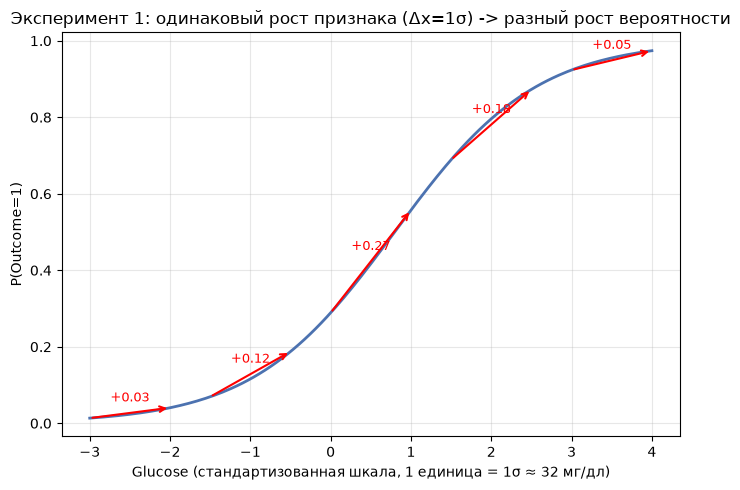

In [6]:
def scale_number(x, mean, std):
    return (x - mean) / std

w_glucose = coefs['Glucose']
b0 = logreg.intercept_[0]

chances_change = []
glu_grid = np.linspace(glu_mean - 3*glu_std, glu_mean + 4*glu_std, 200)
glu_grid_scaled = scale_number(glu_grid, glu_mean, glu_std)

p_grid = 1 / (1 + np.exp(-(b0 + w_glucose * glu_grid_scaled)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(glu_grid_scaled, p_grid, color='#4C72B0', lw=2)

for init_value in [glu_mean - 3*glu_std, glu_mean - 3*glu_std/2, glu_mean, glu_mean + 3*glu_std/2, glu_mean + 3*glu_std]:

    z0 = scale_number(init_value, glu_mean, glu_std) # initial point (raw)
    x0 = b0 + w_glucose * z0 #  chances on initial point
    p0 = 1 / (1 + np.exp(-(x0))) # proba on initial point


    # сдвиг на 1σ в исходных единицах Glucose — это и есть Δz=1 в стандартизованной шкале
    z1 = scale_number(init_value + glu_std, glu_mean, glu_std) # step from initial point 

    x1 = b0 + w_glucose * z1 # chances after step from initial point 
    p1 = 1 / (1 + np.exp(-(x1))) # proba after step from initial point 

    chances_change.append(x1 - x0)

    ax.annotate('', xy=(z0 + 1, p1), xytext=(z0, p0), arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text(z0 + 0.5, (p0 + p1) / 2 + 0.03, f'+{p1 - p0:.2f}', color='red', fontsize=9, ha='center')

ax.set_xlabel('Glucose (стандартизованная шкала, 1 единица = 1σ ≈ 32 мг/дл)')
ax.set_ylabel('P(Outcome=1)')
ax.set_title('Эксперимент 1: одинаковый рост признака (Δx=1σ) -> разный рост вероятности')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# убедимся, что изменение шансов было постоянным
chances_change

[np.float64(1.131154587194597),
 np.float64(1.1311545871945956),
 np.float64(1.131154587194596),
 np.float64(1.131154587194596),
 np.float64(1.1311545871945956)]

**Что мы наблюдаем:** одинаковый шаг признака $\Delta x=1\sigma$ и одно и то же изменение шансов 1.13$ даёт прирост вероятности $+0.12$ около $z=-1$, вырастает до $+0.27$ около $z=0$. Далее прирост снова падает — сначала до $+0.13$ около $z=2$, а далее — до +0.05. 

Это наблюдение будет верно **для любого пациента одинаково** — сдвиг $\Delta z=k\beta_j$ не зависит от того, какое конкретно значение признака было у пациента до этого, нули лишь упростили нам код. 

Теперь посмотрим на рост веса при фиксированном значении признакаи. 

### Эксперимент 2 — растёт вес, признак фиксирован. 

Рассмотрим тот же признак Glucose. Пристальный взгляд на формулу $\Delta z=x_j(\beta_j'-\beta_j)$ позволяет заметить, что сдвиг $z$ пропорционален **значению признака у конкретного пациента**. Если у пациента $x_j=0$ (например, тот же Glucose ровно на среднем уровне выборки), то множитель — ноль, и неважно, насколько сильно поменяется вес: $\Delta z$ всё равно будет 0. 

Поэтому только среднего пациента мы рассматривать не будем, а рассмотрим ряд возможных пациентов при изменении **относительного вклада веса от 0 до 100**. Рассматривать сам вес не так продуктивно — он всегда занимает сколько-то "массы" от других.  


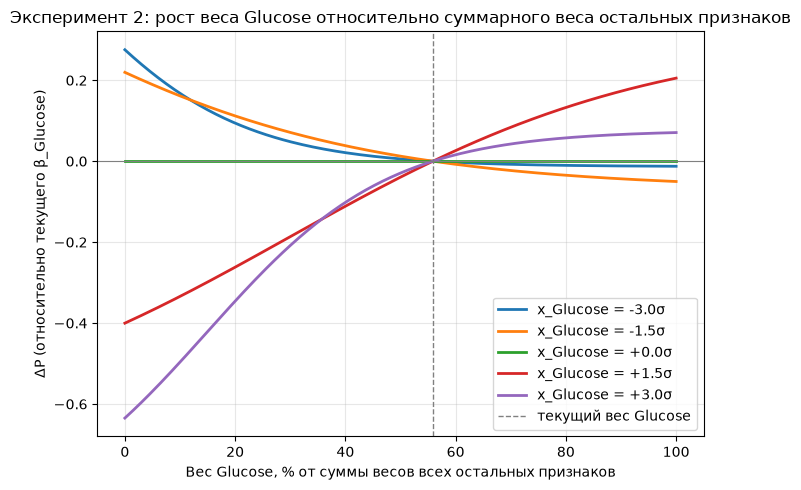

In [8]:
# суммарный вес всех ОСТАЛЬНЫХ признаков (по модулю) -- это и есть "всё остальное, вместе взятое"
w_others_sum = coefs.drop('Glucose').abs().sum()

# относительный вклад веса Glucose: от 0% (вес=0) до 100% (вес Glucose сравнялся с суммой всех остальных)
rel_share = np.linspace(0, 1, 200)
w_grid = rel_share * w_others_sum

patient_z_values = [-3, -1.5, 0,  1.5, 3]  # в стандартизованной шкале (единицы σ)

fig, ax = plt.subplots(figsize=(7, 5))

for z_patient in patient_z_values:
    p_old = 1 / (1 + np.exp(-(b0 + w_glucose * z_patient)))
    p_new_grid = 1 / (1 + np.exp(-(b0 + w_grid * z_patient)))
    delta_p_grid = p_new_grid - p_old
    ax.plot(rel_share * 100, delta_p_grid, lw=2, label=f'x_Glucose = {z_patient:+.1f}σ')

ax.axvline(w_glucose / w_others_sum * 100, color='gray', ls='--', lw=1, label='текущий вес Glucose')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Вес Glucose, % от суммы весов всех остальных признаков')
ax.set_ylabel('ΔP (относительно текущего β_Glucose)')
ax.set_title('Эксперимент 2: рост веса Glucose относительно суммарного веса остальных признаков')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Что мы наблюдаем:** 

Первое — направление сдвига вероятности зависит от **знака** $x_j$ у пациента. У пациентов с повышенной глюкозой ($+1.5\sigma$, $+3\sigma$) рост веса повышает вероятность — линии идут вверх правее точки пересечения; у пациентов с пониженной ($-1.5\sigma$, $-3\sigma$) — понижает, линии идут вниз.

Второе — величина эффекта не пропорциональна $|x_j|$, а зависит от того, где стартует признак относительно крутой части сигмоиды.
-  типичный пациент, в силу стандартизации данных, имеет признак равный 0 и ничего не теряет и не приобретает при изменении веса.
 - пациент, чьё значение глюкозы было изначально велико ($+3\sigma$), теряет **больше всех**, если вес обнулить от текущего значения ($\Delta P\approx-0.63$). Но при дальнейшем росте веса тот же пациент выигрывает **меньше всех** ($\Delta P\approx+0.07$ на правом краю).
- пациент со значением $+1.5\sigma$ получил самый сильный прирост при увеличении веса от текущего значения ($\Delta P\approx+0.21$). Его стартовая точка не насыщена, а ближе к крутой середине сигмоиды, поэтому он реагирует сильнее, чем  «крайний» пациент $+3\sigma$.
- для пациентов с низким уровнем глюкозы вероятность заметно **растёт** при уменьшении веса ($\Delta P\approx+0.22$ для $-1.5\sigma$), но лишь слегка **снижается** при дальнейшем росте веса ($\Delta P\approx-0.05$) — та же асимметрия из-за насыщения сигмоиды, только с другой стороны.


Итого мы видим, что здесь чувствительность интересующей нас величины — вероятности — и к сдвигу признака, и к сдвигу веса зависит не от самого $x_j$ или $\beta_j$ по отдельности, а от того, куда попадает итоговый $z=\beta_0+\sum_j\beta_jx_j$ на кривой сигмоиды. Центральное значение усиливает сдвиг, насыщенные края почти любой сдвиг гасят. Стало быть — мы на практике видим наш теоретический тезис — интерпретировать веса надо в связке с link-functiom.

## Блок 2. GLM #2 — Poisson (счётные данные)

Второй член GLM-семьи — Poisson-регрессия для данных, интерпретируемых как число событий за интервал. Link функция здесь имеент вид:

$$ \log(\mathbb{E}[Y|X])=\beta_0+\sum_j \beta_j x_j $$

И из уроков нам известно, что для анализа весов Пуассоновской регресcии используют **IRR** (incidence rate ratio) коэффициент отношения интенсивностей: во сколько раз меняется ожидаемое число событий $μ$ при увеличении признака на $1$. Формула: для признака $x_j: IRR =e(w_j)$ (для сдвига на $Δx: e(w_jΔx)$). Значение $>1$ — рост интенсивности, $<1$ — падение.

Посмотрим на него в действии на наборе данных об успеваемости `student-mat.csv` и признаке `absences` — число пропущенных занятий. Чтобы построить Пуассоновскую регрессию, нам понадобится библиотека `statsmodels`.

**Почему не sklearn?**
В sklearn формально есть `PoissonRegressor` — он даёт точечные оценки коэффициентов и прогноз, но не считает стандартные ошибки, доверительные интервалы и p-value. В блоке про логистическую регрессию мы увидели нетривиальность анализа коэффициентов, и сейчас немного схитрим — будем анализировать значимость, используя статистический аппарат `statsmodels`. Заодно немного прощупаем границы такой хитрости.

**Напоминание.** p-value — это вероятность получить наблюдаемую или ещё более выраженную (в смысле нулевой гипотезы) оценку в ходе эксперимента, если предположить, что проверяемый эффект случаен (то есть так называемая нулевая гипотеза верна). В нашем случае, это вероятность получить ненулевой коэффициент при условии, что на самом деле истинного эффекта нет. Если такая вероятность маленькая (мы рассмотрим $p<0.05$) , то при заданных допущениях модели маловероятно получить настолько ненулевой вес, если бы признак на самом деле не был связан с таргетом (при фиксированных остальных признаках).

Важные слова здесь — «при заданных допущениях модели». Вокруг любого стат теста всегда есть условия модели. Здесь p-value считается через t-статистику $t=\hat\beta_j/SE(\hat\beta_j)$, а $SE$ напрямую зависит от того, насколько верно модель описывает дисперсию данных. Если допущение о дисперсии неверно, весь расчёт значимости идёт по сбитой шкале — даже если сама точечная оценка $\hat\beta_j$ осталась прежней. Это понадобится нам при анализе результатов. 


In [9]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

data_students = pd.read_csv('https://github.com/SadSabrina/open-xai-materials/raw/refs/heads/main/data/student-mat.csv', sep=';')

model_poisson = smf.glm('absences ~ studytime + health + goout + failures', data=data_students, family=sm.families.Poisson()).fit()

irr = np.exp(model_poisson.params)
ci = model_poisson.conf_int()

irr_table = pd.DataFrame({
    'IRR': irr.round(3),
    'IRR_low': np.exp(ci[0]).round(3),
    'IRR_high': np.exp(ci[1]).round(3),
    'p_value': model_poisson.pvalues.round(4),
    'p_value < 0.05': model_poisson.pvalues.round(4) < 0.05,
})
irr_table

,IRR,IRR_low,IRR_high,p_value,p_value < 0.05
Intercept,6.669,5.461,8.144,0.0000,True
studytime,0.911,0.865,0.959,0.0004,True
health,0.964,0.936,0.992,0.0138,True
goout,1.042,1.004,1.082,0.0288,True
failures,1.091,1.036,1.149,0.0010,True


**Что мы наблюдаем:** 
- Все эффекты значимы.
- каждая дополнительная единица `studytime` связана со снижением ожидаемого числа пропусков на $\approx 9\%$ (IRR $\approx 0.91$), 
- `health` снижает пропуски на $\approx 4\%$, 
- каждый `failures` в прошлом связан с с ростом на $\approx 9\%$ (IRR $\approx 1.09$); 
- `goout` увеличивает пропуски на $\approx 4\%$


Отлично. С одной стороны мы на данном этапе из коробки получили внушительный статистический анализ. Однако, здесь, как ив любом результате нужно убедиться, что мы можем доверять такой значимости. 

**Хороший инструмент хорош в рамках среды, для которой он создан.**

Как и у любого инструмента, у p-value есть важная особенность: он корректен только при выполнении предположений модели.

В Poisson-регрессии значимость коэффициентов считается через стандартную ошибку:

$$t=\frac{\hat\beta}{SE(\hat\beta)}$$

Сам коэффициент $\hat\beta$ оценивается по данным, а стандартная ошибка вычисляется исходя из предположений модели. Одно из главных предположений Пуассона —

$\operatorname{Var}(Y)=\mathbb E[Y].$

Если данные шумные и выходят за предположения модели (это называется овердисперсией), модель недооценивает стандартные ошибки. Дальше возникает неприятный цикл цепочка:

* модель занижает SE;
* из-за этого t-статистика становится слишком большой;
* а p-value — слишком маленьким.

Получается ложная уверенность, что эффект статистически значим. В наших данных это как раз выполняется: среднее ≈ 5, а дисперсия ≈ 64. То есть больше ожидаемой примерно в 11 раз. Если бы различие сводилось только к масштабу дисперсии, стандартные ошибки должны были бы увеличиться примерно в $\sqrt{11.2}\approx3.35$ раза и повлиять на p-value.

Чтобы проверить эту гипотезу, построим модель Negative Binomial. Она использует ту же логарифмическую link-функцию ($\log(\mathbb E[Y|X])=\beta_0+\sum_j\beta_jx_j$),

но отличается другим предположением о распределении отклика. Вместо требования
равенства дисперсии матожиданию, модель Negative Binomial допускает, что дисперсия может быть больше среднего:

$$\operatorname{Var}(Y)=\mu+\alpha\mu^2,$$

где параметр $\alpha>0$ оценивается по данным и определяет степень овердисперсии.

Если причина действительно в овердисперсии, то сами коэффициенты модели должны остаться близкими к оценкам Poisson-регрессии — ведь обе модели описывают одну и ту же зависимость между признаками и целевой переменной. Зато стандартные ошибки и p-value могут измениться весьма существенно, поскольку теперь они будут вычисляться при более реалистичном предположении о дисперсии данных.


In [10]:
dispersion_ratio = data_students['absences'].var() / data_students['absences'].mean()
print('mean(absences) = %.2f,  var(absences) = %.2f' % (data_students['absences'].mean(), data_students['absences'].var()))
print('Var/Mean(absences):', round(dispersion_ratio, 2), '(при Poisson ожидаем необходимо ~1)')

model_nb = smf.glm('absences ~ studytime + health + goout + failures', data=data_students, family=sm.families.NegativeBinomial()).fit()

irr_nb = np.exp(model_nb.params)
comparison_glm = pd.DataFrame({
    'IRR_Poisson': irr.round(3),
    'p_Poisson': model_poisson.pvalues.round(3),
    'p_sign_Poisson': model_poisson.pvalues.round(3) < 0.05,
    'IRR_NegBinom': irr_nb.round(3),
    'p_NegBinom': model_nb.pvalues.round(3),
    'p_sign_NegBinom': model_nb.pvalues.round(3) < 0.05,
})
comparison_glm

mean(absences) = 5.71,  var(absences) = 64.05
Var/Mean(absences): 11.22 (при Poisson ожидаем необходимо ~1)


/Users/sabrinasadieh/Code/xai_course/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


,IRR_Poisson,p_Poisson,p_sign_Poisson,IRR_NegBinom,p_NegBinom,p_sign_NegBinom
Intercept,6.669,0.000,True,6.738,0.000,True
studytime,0.911,0.000,True,0.902,0.122,False
health,0.964,0.014,True,0.970,0.433,False
goout,1.042,0.029,True,1.035,0.486,False
failures,1.091,0.001,True,1.120,0.127,False


Что и требовалось показать — мы видим, что веса близки, однако pvalue — различны для всех признаков, кроме одного. 

In [11]:
se_compare = pd.DataFrame({
    'SE_Poisson': model_poisson.bse.round(4),
    'SE_NegBinom': model_nb.bse.round(4),
    'во сколько раз шире (NB/Poisson)': (model_nb.bse / model_poisson.bse).round(2),
})
se_compare

,SE_Poisson,SE_NegBinom,во сколько раз шире (NB/Poisson)
Intercept,0.1019,0.2652,2.60
studytime,0.0265,0.0667,2.52
health,0.0150,0.0394,2.62
goout,0.0189,0.0495,2.61
failures,0.0265,0.0741,2.80


**Вывод: прежде чем доверять значимости в GLM — всегда проверяйте, подходит ли выбранное распределение к данным** (`Var/Mean` для Poisson — самая дешёвая из таких проверок).

Перейдем к третьему типу регрессии. 

**Для интересующихся. Причем тут вообще стандартная ошибка?**

Коэффициенты GLM оцениваются методом максимального правдоподобия (Maximum Likelihood Estimation, MLE). Для MLE существует фундаментальный результат математической статистики: при достаточно большом объёме выборки оценка параметров имеет приближённо нормальное распределение

$$\hat\beta \overset{approx}{\sim} N \left(\beta, I(\beta)^{-1}\right)$$

где $I(\beta)$ — матрица информации Фишера. Поэтому стандартная ошибка каждого коэффициента — это квадратный корень из соответствующего диагонального элемента матрицы $I(\beta)^{-1}$.

Интуитивно информация Фишера измеряет, насколько острым получился максимум функции правдоподобия. Если максимум узкий и крутой, параметры определены достаточно точно — стандартные ошибки малы. Если же максимум “пологий”, существует много почти одинаково хороших значений параметров, поэтому неопределённость возрастает, а вместе с ней растут и стандартные ошибки.

Для обычной линейной регрессии эта общая теория сводится к знакомой формуле
$$\operatorname{Var}(\hat\beta)=\sigma^2(X^TX)^{-1}$$

где $\sigma^2$ — дисперсия шума, а матрица $(X^TX)^{-1}$ зависит только от признаков.

Отсюда следует ещё одно уже знакомое нам следствие. Если признаки сильно коррелируют между собой (мультиколлинеарность), диагональные элементы $(X^TX)^{-1}$ увеличиваются. Поэтому растут стандартные ошибки коэффициентов, расширяются доверительные интервалы и увеличиваются p-value. Именно это мы наблюдали при обсуждении VIF: сам коэффициент мог почти не измениться, но уверенность в его оценке снижалась.

Для GLM логика остаётся той же самой, только вместо простой матрицы X^TX появляется
$$\operatorname{Var}(\hat\beta)\approx (X^TWX)^{-1},$$


где веса W определяются выбранным распределением и его функцией дисперсии. Поэтому смена семейства от Poisson 4 Negative Binomial почти не меняет сами коэффициенты, но меняет матрицу W, а вместе с ней — стандартные ошибки и p-value.

Получается красивая общая картина: разные проблемы модели (мультиколлинеарность, маленькая выборка, неверно выбранное распределение и др.) влияют на статистическую значимость по-разному, но итог один и тот же — они увеличивают неопределённость оценки коэффициента, то есть его стандартную ошибку.

## Блок 3. GLM #3 — Gamma (скошенная положительная величина)

Третий член GLM-семьи предназначен для непрерывной, строго положительной и скошенной вправо величины. Типичный пример — денежные суммы, длительности или страховые выплаты. Мы возьмём классический датасет медицинских страховых расходов (`insurance.csv`: задача регрессии возраста, ИМТ, числа детей, курения и регион на`charges` — сумма страховых выплат за год).

Как и для Пуассоновской регресии, для Gamma-модели справедлива логарифмическая функция связи — как одна из функций. 

$$\log(\mathbb E[Y|X])=\beta_0+\sum_j\beta_jx_j.$$

Однако здесь важно увидеть и закрепить себе момент различия. В GLM есть две независимые вещи:

1. распределение таргета (семейство);
2. функция связи (link).

Отсюда, в определении мы перешли в новое семейство распределения таргета, но остались с той же функцией связи. Но это никак не ограничивает нас от использования других функций связи внутри семейства. Посмотрим, к чему это может привести. 

Что касается интерпретации весов — здесь она целиком как в Пуассоновской регрессии. 

charges: min=1122 max=63770 skew=1.52

Средние charges по курению:
smoker
no      8434.3
yes    32050.2
Name: charges, dtype: float64


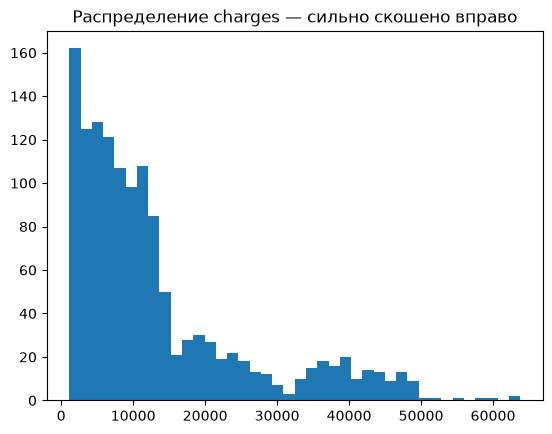

In [12]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df_ins = pd.read_csv(url)

print('charges: min=%.0f max=%.0f skew=%.2f' % (df_ins['charges'].min(), df_ins['charges'].max(), df_ins['charges'].skew()))
print()
print('Средние charges по курению:')
print(df_ins.groupby('smoker')['charges'].mean().round(1))

plt.hist(df_ins['charges'], bins=40);
plt.title('Распределение charges — сильно скошено вправо');

По простому сравнению средних видно, что курильщики платят примерно в 3.8 раза больше, чем некурящие. Это заранее подсказывает, что признак smoker должен оказаться одним из самых сильных факторов модели. 

Закодируем категориальные признаки и обучим Gamma-GLM, однако сходу сделать это не выйдет — здесь есть подвох для нас. В statsmodels для семейства Gamma по умолчанию используется inverse-link, а не логарифмическая связь.

Формально, как вы прочли выше, обе функции связи допустимы, но это вовсе не означает, что они одинаково хорошо подходят для любых данных. Так что чтобы потрогать это руками, построим сразу две модели: одну с настройками по умолчанию, а вторую — с явно указанным log-link.

In [13]:
df_enc = pd.get_dummies(df_ins, columns=['sex', 'smoker', 'region'], drop_first=True)
X_ins = df_enc.drop(columns=['charges']).astype(float)
y_ins = df_enc['charges']

Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_ins, y_ins, test_size=0.25, random_state=42)

from sklearn.metrics import r2_score, mean_squared_error

Xi_train_c = sm.add_constant(Xi_train)
Xi_test_c = sm.add_constant(Xi_test)

# БЕЗ явного link -- дефолтный inverse link
model_wrong = sm.GLM(yi_train, Xi_train_c, family=sm.families.Gamma())
res_wrong = model_wrong.fit()
pred_wrong = res_wrong.predict(Xi_test_c)

# С явным log-link -- корректно
model_right = sm.GLM(yi_train, Xi_train_c, family=sm.families.Gamma(link=sm.families.links.Log()))
res_right = model_right.fit()
pred_right = res_right.predict(Xi_test_c)

print('Gamma, inverse link: R2=%.4f' % r2_score(yi_test, pred_wrong))
print('Gamma, log-link:         R2=%.4f' % r2_score(yi_test, pred_right))

Gamma, inverse link: R2=-239.4237
Gamma, log-link:         R2=0.6491


/Users/sabrinasadieh/Code/xai_course/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


**Вывод:** с inverse связью $R^2\approx-239$ — то есть модель оказалась намного хуже, чем прогноз одним средним значением (отрицательный $R^2$  означает «хуже константы»). 

Для данного распределения использование `inverse` ($\frac{1}{\mu}$), как функции связи не корректно. После преобразования все большие значения сжимаются почти к нулю и оптимизация модели становится нестабильной.


После перехода к логарифмической связи дает $R^2\approx0.65$ — на порядки лучше. Посмотрим на коэффициенты. 

In [14]:
effect = pd.DataFrame({
    'coef': res_right.params,
    'exp(coef)': np.exp(res_right.params),
    'p_value': res_right.pvalues,
}).round(4)
effect.sort_values('p_value')

,coef,exp(coef),p_value
const,7.4002,1636.3898,0.0000
age,0.0288,1.0292,0.0000
children,0.0762,1.0791,0.0000
smoker_yes,1.4972,4.4694,0.0000
bmi,0.0135,1.0136,0.0003
region_southwest,-0.1419,0.8677,0.0203
region_southeast,-0.1187,0.8880,0.0552
sex_male,-0.0568,0.9448,0.1855
region_northwest,-0.0552,0.9463,0.3645


В силу той же функции связи их можно интерпретировать так же, как мы делали это в Poisson-регрессии. 

Но как мы увидели ранее, качество прогноза не означает, что модели можно полностью доверять. Здесь также справедливо, что Gamma-регрессия имеет собственные предположения о распределении отклика и характере остатков. А именно:

* целевая переменная должна быть строго положительной;
* её распределение должно быть близко к Gamma-распределению;
* дисперсия должна расти вместе со средним (в Gamma это естественное свойство распределения);
* связь между признаками и математическим ожиданием должна быть корректно описана выбранной link-функцией (это мы увидели глазами).

В нашем случае все страховые выплаты положительны, а правосторонняя асимметрия делает Gamma естественным кандидатом. Однако остальные предположения лучше не принимать на веру, а проверять с помощью диагностики модели. 

Мы же сейччас сосредоточимся на устройстве модели и интерпретации коэффициентов, а уроки по подробной диагностике GLM рассмотрим отдельно. 

TO DO: мы хотим такие?

## Блок 4. GAM — решение, когда только числа на признак мало

У всех рассмотренных моделей остаётся важное ограничение — мы предполагаем, что влияние каждого признака не зависит от остальных. Например, коэффициент при bmi считается одинаковым и для курящих, и для некурящих.

Но действительно ли лишний килограмм веса одинаково влияет на расходы обеих групп? 
Для работы в таких случаях, как мы знаем, можно перейти к GAM (Generalized Additive Model). В ней мы:

* по-прежнему моделируем условное математическое ожидание;
* можем выбирать распределение целевой переменной;
* используем функцию связи g

но при этом вместо одного коэффициента на признак разрешаем модели подобрать для него отдельную гладкую функцию. Общий вид GAM:

$$g(\mathbb{E}[Y|X]) = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_m(x_m)$$

То есть, от вопроса коэффициентов:
- На сколько изменяется линейный предиктор при увеличении признака на единицу?

Мы уходим к:
- Как в целом меняется линейный предиктор при разных значениях признака?

Посмотрим, как это работает на практике. 


## pyGAM

Стандартная библиотека для GAM — `pyGAM`. В ней структуру модели задают с помощью **термов** — отдельных компонентов формулы. Основные из них: `s, l, f, te`, где:

- `l()` — линейный терм
    `l(0)` —  линейный эффект первого столбца: $\beta_1x_1$.
- `s()` — гладкий терм
    s(0) — гладкая (нелинейня, но дифференцируемая) функция для первого столбца: $f_1(x_1)$.
- `f()` — категориальный терм
    f(2) — означает, что третий столбец рассматривается как категориальный признак и модель под капотом оценивает отдельный вклад для каждой категории. 
- `te()` — совместный эффект нескольких признаков
    te(0, 1) строит гладкую функцию сразу от двух признаков: $f_{1,2}(x_1,x_2)$.

Соберем первую модель, используя гладкие и категориальные term's.

In [15]:
from pygam import LinearGAM, s, f, te
from sklearn.linear_model import LinearRegression

lr_ins = LinearRegression().fit(Xi_train, yi_train)
pred_lr_ins = lr_ins.predict(Xi_test)
print('Linear Regression: R2=%.4f' % r2_score(yi_test, pred_lr_ins))

cols = list(Xi_train.columns)
print(cols)

# s() -- гладкая функция для непрерывных (age, bmi), 
# f() -- категориальный терм для бинарных/дискретных

gam_add = LinearGAM(s(0) + s(1) + f(2) + f(3) + f(4) + f(5) + f(6) + f(7))
gam_add.gridsearch(Xi_train.values, yi_train.values, lam=np.logspace(-2, 3, 15), progress=False)
pred_add = gam_add.predict(Xi_test)
print('GAM аддитивная (age, bmi гладкие): R2=%.4f' % r2_score(yi_test, pred_add))

Linear Regression: R2=0.7673
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
GAM аддитивная (age, bmi гладкие): R2=0.7602


**Вывод:** 

Построенный вариант GAM  — чисто аддитивный по каждому признаку. Она имеет вид, где прогноз — сумма частных эффектов:

$$\hat y = \beta_0 +f_{\text{age}}(\text{age}) +f_{\text{bmi}}(\text{bmi})
+\dots$$



Заметим, что ($R^2\approx0.760$) практически не отличается от обычной линейной регрессии ($R^2\approx0.767$). Отсюда переход от коэффициентов к функциям сам по себе может ничего не дать (а мы теряем в некотором смысле простоту интерпретации). 

Однако, аддитивности по каждому признаку может быть недостаточно, признаки могут взаимодействовать и когда у нас есть гипотезы, мы можем это учесть. Добавим явный терм взаимодействия `te(bmi, smoker)` (сглаживание по двум признакам сразу).

In [16]:
gam_inter = LinearGAM(s(0) + te(1, 4) + f(2) + f(3) + f(5) + f(6) + f(7))
gam_inter.gridsearch(Xi_train.values, yi_train.values, lam=np.logspace(-2, 3, 10), progress=False)
pred_inter = gam_inter.predict(Xi_test)
print('GAM + te(bmi, smoker):                R2=%.4f' % r2_score(yi_test, pred_inter))

GAM + te(bmi, smoker):                R2=0.8704


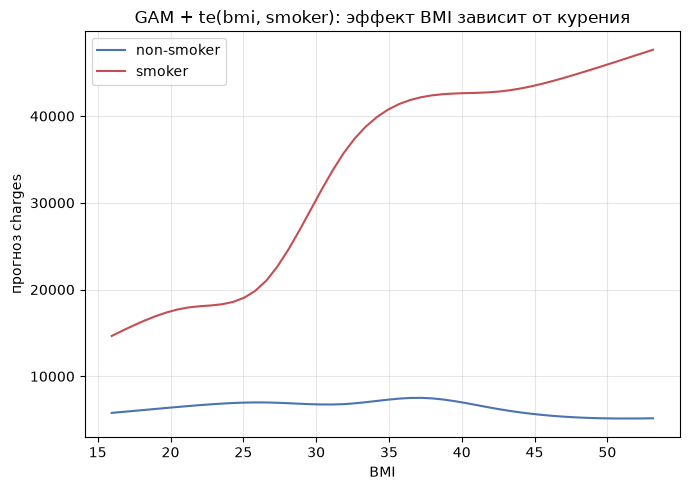

In [17]:
base = Xi_train.median()
bmi_grid = np.linspace(Xi_train['bmi'].min(), Xi_train['bmi'].max(), 50)

def make_grid(smoker_val):
    grid = pd.DataFrame([base.values] * len(bmi_grid), columns=cols)
    grid['bmi'] = bmi_grid
    grid['smoker_yes'] = smoker_val
    return grid

pred_nonsmoker = gam_inter.predict(make_grid(0).values)
pred_smoker = gam_inter.predict(make_grid(1).values)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bmi_grid, pred_nonsmoker, label='non-smoker', color='#4C72B0')
ax.plot(bmi_grid, pred_smoker, label='smoker', color='#C44E52')
ax.set_xlabel('BMI'); ax.set_ylabel('прогноз charges')
ax.set_title('GAM + te(bmi, smoker): эффект BMI зависит от курения')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**

Явный терм взаимодействия подняла качество с $R^2\approx0.760$ до $R^2\approx0.870$. График дает нам обоснования — ля **некурящих** прогноз почти не зависит от BMI (5785 при BMI=16, 5162 при BMI=53 — плоская линия). Для **курящих** прогноз растёт втрое (14649 $\to$ 47642), причём заметно ускоряется примерно с BMI$\approx$30 — это ровно клинический порог ожирения. GLM или GAM с гладкими взаимодействиямине уловили это. 


Уносим на зметку — гибкость формы одного признака может почти ничего не добавить — и с точки зрения интерпретируемости при таком результате лучше оставаться на линейной модели. Гипотезы о взаимодействия, найденные во время EDA могут помочь построить модель более контроллируемую, чем при использовании алгоритмов сложнее. 

## Блок 5. GAMI-Net — обобщение систематического взаимодействия

В Блоке 4 мы вручную добавили взаимодействие `te(bmi, smoker)`, исходя из наших знаний о данных. И, конечно, знание у нас может быть не всегда — признаков может быть слишком много иом признаки могут быть сложными для осмысленного анализа. Перебор, как решение всех вариантов пар не всегда возможен. 

Отсюда иногда полезно перейти к автоматизации и использовать изученную GAMI-Net. Она автоматизирует поиск взаимодействий и имеет вид: 

$$g(\mathbb{E}[y|x]) = \mu + \sum_{j \in S_1} h_j(x_j) + \sum_{(j,k)\in S_2} f_{jk}(x_j, x_k)$$

Каждый $h_j$ — своя маленькая нейросеть (main effect), каждый $f_{jk}$ — своя сеть на пару признаков (interaction). 

В GAMI-Net из [работы](https://arxiv.org/pdf/2003.07132), обучение идёт в 3 этапа с ограничениями (разреженность, наследственность, **marginal clarity** — ортогональность $\int h_jf_{jk}\,dF\approx0$, чтобы main effect и interaction не «путались»). 

Мы с вами пойдем в два шага:
1. Cсоберём упрощённую версию — без этих ограничений — посмотрим, что теряется без них.
2. Соберем близкую к [оригинальной](https://github.com/SelfExplainML/GamiNet/blob/master/gaminet/gaminet.py) версию и сравнив ее со статистической GAM.

Начнем с упрощенной. 

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

class MainEffectNetwork(nn.Module):
    # нейросеть для main effect одного признака
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 10), nn.ReLU(), nn.Linear(10, 10), nn.ReLU(), nn.Linear(10, 1))
    def forward(self, x):
        return self.net(x)

class InteractionNetwork(nn.Module):
    # нейросеть для взаимодействия двух признаков
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 20), nn.ReLU(), nn.Linear(20, 10), nn.ReLU(), nn.Linear(10, 1))
    def forward(self, x):
        return self.net(x)

class SimpleGAMINet(nn.Module):
    # y = intercept + sum_i h_i(x_i) + f(x_0, x_1)
    def __init__(self, n_features):
        super().__init__()
        self.n_features = n_features
        self.main_effects = nn.ModuleList([MainEffectNetwork() for _ in range(n_features)])
        self.interaction = InteractionNetwork()
        self.intercept = nn.Parameter(torch.zeros(1))

    def components(self, x):
        # h_j по отдельности и f_inter отдельно -- нужно для расчёта marginal clarity (Omega) и для этапа 2 (обучение на остатке)
        h = [self.main_effects[i](x[:, i:i+1]).squeeze(1) for i in range(self.n_features)]
        f_inter = self.interaction(x[:, :2]).squeeze(1)
        return h, f_inter

    def forward(self, x):
        h, f_inter = self.components(x)
        out = self.intercept.expand(x.shape[0])
        for hi in h:
            out = out + hi
        return out + f_inter

Чтобы контроллировать успех обучения чуть явнее, чем по лоссу — сгенерируем синтетику с **известными** эффектами:

- два main effects (линейный по $x_0$, нелинейный $\sin$ по $x_1$),
- одно взаимодействие $(x_0,x_1)$, 
- два «шумовых» признака $x_2,x_3$ без эффекта

и на них обучим модель. 

Epoch 100, Loss: 0.5842
Epoch 200, Loss: 0.2508
Epoch 300, Loss: 0.2388


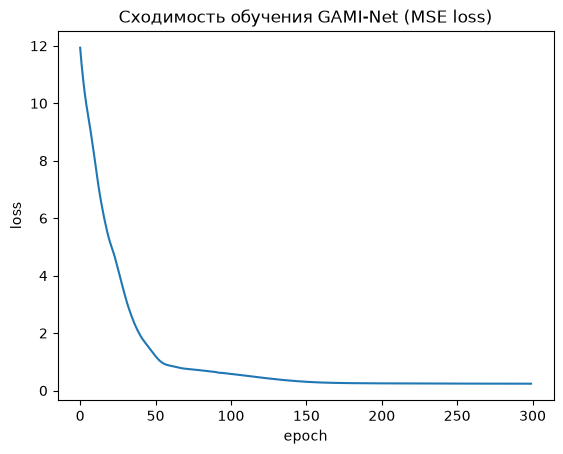

In [19]:
np.random.seed(42)
torch.manual_seed(42)

n_samples, n_features = 1000, 4
X_gami = np.random.randn(n_samples, n_features)
y_gami = (
    2.0 * X_gami[:, 0]                    # main effect 1 (линейный)
    + 3.0 * np.sin(2.0 * X_gami[:, 1])    # main effect 2 (нелинейный)
    + 1.5 * X_gami[:, 0] * X_gami[:, 1]   # interaction(0,1)
    + 0.5 * np.random.randn(n_samples)    # шум
)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(X_gami, y_gami, test_size=0.3, random_state=42)
Xg_train_t = torch.tensor(Xg_train, dtype=torch.float32)
yg_train_t = torch.tensor(yg_train, dtype=torch.float32)
Xg_test_t = torch.tensor(Xg_test, dtype=torch.float32)

gami_model = SimpleGAMINet(n_features=n_features)
optimizer = optim.Adam(gami_model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
gami_model.train()
for epoch in range(300):
    optimizer.zero_grad()
    preds = gami_model(Xg_train_t)
    loss = criterion(preds, yg_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:3d}, Loss: {loss.item():.4f}')

plt.plot(losses);
plt.title('Сходимость обучения GAMI-Net (MSE loss)');
plt.xlabel('epoch'); plt.ylabel('loss');

In [20]:
gami_model.eval()
with torch.no_grad():
    yg_pred_gami = gami_model(Xg_test_t).cpu().numpy()

print('GAMI-Net:               R2=%.4f  MSE=%.4f' % (r2_score(yg_test, yg_pred_gami), mean_squared_error(yg_test, yg_pred_gami)))

gam_baseline = LinearGAM(s(0) + s(1)  + s(2) + s(3)).fit(Xg_train, yg_train)
gam_gt_interaction_baseline = LinearGAM(s(0) + s(1) + te(0, 1) + s(2) + s(3)).fit(Xg_train, yg_train)

yg_pred_gam = gam_baseline.predict(Xg_test)
yg_pred_gam_interaction = gam_gt_interaction_baseline.predict(Xg_test)

print('GAM без взаимодействий: R2=%.4f  MSE=%.4f' % (r2_score(yg_test, yg_pred_gam), mean_squared_error(yg_test, yg_pred_gam)))
print('GAM с истинным взаимодействием: R2=%.4f  MSE=%.4f' % (r2_score(yg_test, yg_pred_gam_interaction), mean_squared_error(yg_test, yg_pred_gam_interaction)))

GAMI-Net:               R2=0.9627  MSE=0.4199
GAM без взаимодействий: R2=0.7515  MSE=2.7939
GAM с истинным взаимодействием: R2=0.9764  MSE=0.2656


GAMI-Net (с interaction-сетью) даёт $R^2\approx0.963$, GAM без взаимодействия на этой синтетической задаче дает $R^2\approx0.752$, GAM с взаимодействием дает $R^2\approx0.9762$.

Мы получили прирост, **связанный с взаимодействиями**, но не связанный с решением задачи градиетным спуском и нейросетевым подходом. Давайте попробуем мобить статистическую GAM, реализовав pipeline обучения почти целиком повторяющий статью. Для этого нам нужно будет сделать три этапа:

1. **Main effects отдельно.** Обучаем все $h_j(x_j)$ на полном таргете, без interaction-сети вообще.
2. **Interaction на остатках.** Замораживаем main effects, обучаем interaction-сеть не на $y$, а на **остатке** $y - \sum_jh_j(x_j)$ — то есть только на той части, которую main effects объяснить не смогли. Это само по определению подталкивает к ортогональности, так как interaction-сеть не видит то, что уже объяснено.
3. **Совместное дообучение.** Размораживаем всё и дообучаем вместе, уже со штрафом $\Omega$, для полировки.

**Отличие от [официальной реализации](https://github.com/SelfExplainML/GamiNet)** в таком сетапе остается в деталях — отбор эффектов, поиск кандидатов на взаимодействие, monotonicity-ограничения, early stopping по валидации. У нас этого нет: на синтетике с 2 известными эффектами отбирать нечего, но код реализации вы можете глянуть по ссылке выше.

In [21]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        y_pred = model(Xg_test_t).numpy()
    r2 = r2_score(yg_test, y_pred)

    grid = torch.linspace(-3, 3, 100).unsqueeze(1)
    with torch.no_grad():
        h0 = model.main_effects[0](grid).squeeze().numpy()
        h1 = model.main_effects[1](grid).squeeze().numpy()
    x_np = grid.squeeze().numpy()
    true_h0 = 2.0 * x_np
    true_h1 = 3.0 * np.sin(2.0 * x_np)
    corr0 = np.corrcoef(h0 - h0.mean(), true_h0 - true_h0.mean())[0, 1]
    corr1 = np.corrcoef(h1 - h1.mean(), true_h1 - true_h1.mean())[0, 1]
    return r2, corr0, corr1

In [22]:
def train_gami_staged(epochs_stage1=300, epochs_stage2=300, epochs_stage3=200, lam=1.0, seed=42):
    torch.manual_seed(seed)
    model = SimpleGAMINet(n_features=n_features)
    criterion = nn.MSELoss()

    # --- Этап 1: только main effects (interaction в предсказании не участвует) ---
    params_stage1 = list(model.main_effects.parameters()) + [model.intercept]
    opt1 = optim.Adam(params_stage1, lr=0.01)
    for epoch in range(epochs_stage1):
        opt1.zero_grad()
        h, _ = model.components(Xg_train_t)
        pred = model.intercept.expand(Xg_train_t.shape[0])
        for hi in h:
            pred = pred + hi
        loss = criterion(pred, yg_train_t)
        loss.backward()
        opt1.step()

    # --- Этап 2: замораживаем main effects, учим interaction на остатке ---
    for p in model.main_effects.parameters():
        p.requires_grad_(False)
    with torch.no_grad():
        h, _ = model.components(Xg_train_t)
        pred_stage1 = model.intercept.expand(Xg_train_t.shape[0]).clone()
        for hi in h:
            pred_stage1 = pred_stage1 + hi
        residual_stage1 = yg_train_t - pred_stage1

    opt2 = optim.Adam(model.interaction.parameters(), lr=0.01)
    for epoch in range(epochs_stage2):
        opt2.zero_grad()
        f_inter = model.interaction(Xg_train_t[:, :2]).squeeze(1)
        loss = criterion(f_inter, residual_stage1)
        loss.backward()
        opt2.step()

    # --- Этап 3: совместное дообучение. В официальном GAMI-Net здесь два раздельных
    # градиента (две "tape"): main effects обновляются чистым MSE, interaction --
    # MSE + Omega. У нас раньше был один общий backward(mse + lam*omega) на все
    # параметры сразу -- из-за этого Omega могла слегка "тянуть" уже неплохо
    # обученный h_0. Разделяем градиенты так же, как в оригинале.
    for p in model.main_effects.parameters():
        p.requires_grad_(True)

    main_params = list(model.main_effects.parameters()) + [model.intercept]
    inter_params = list(model.interaction.parameters())
    opt_main = optim.Adam(main_params, lr=0.001)
    opt_inter = optim.Adam(inter_params, lr=0.001)

    for epoch in range(epochs_stage3):
        h, f_inter = model.components(Xg_train_t)
        pred = model.intercept.expand(Xg_train_t.shape[0])
        for hi in h:
            pred = pred + hi
        pred = pred + f_inter
        mse = criterion(pred, yg_train_t)
        omega = torch.abs((h[0] * f_inter).mean()) + torch.abs((h[1] * f_inter).mean())

        opt_main.zero_grad()
        opt_inter.zero_grad()

        # main effects видят только mse -- Omega их не касается
        grads_main = torch.autograd.grad(mse, main_params, retain_graph=True)
        # interaction видит mse + штраф за неортогональность
        grads_inter = torch.autograd.grad(mse + lam * omega, inter_params, retain_graph=False)

        for p, g in zip(main_params, grads_main):
            p.grad = g
        for p, g in zip(inter_params, grads_inter):
            p.grad = g

        opt_main.step()
        opt_inter.step()

    return model

In [23]:
model_staged = train_gami_staged()

r2_st, c0_st, c1_st = evaluate(model_staged)
print('Трёхэтапная процедура:   R2=%.4f  corr_h0=%.4f  corr_h1=%.4f' % (r2_st, c0_st, c1_st))

r2, c0, c1 = evaluate(gami_model)
print('Baseline реализация:   R2=%.4f  corr_h0=%.4f  corr_h1=%.4f' % (r2, c0, c1))

Трёхэтапная процедура:   R2=0.9609  corr_h0=0.9978  corr_h1=0.8453
Baseline реализация:   R2=0.9627  corr_h0=0.9992  corr_h1=0.4757


Качество не сильно улучшилось, однако улучшилась структура — трёхэтапная процедура даёт корреляцию $h_1\approx0.845$ —  лучше исходных $\approx0.48$ без ортогональности. При этом $h_0$ остаётся отличным ($\approx0.997$), $R^2\approx0.962$ на уровне лучших предыдущей версии.

Посмотрим на корреляции выученных заивимостей у базовых GAM и затем на сами выученные зависимости глазами и сравним:
- выученные функции с истинными (с точностью до аддитивной константы — она уходит в intercept)
- модели между собой

In [24]:
# gammi-net variatns
grid = torch.linspace(-3, 3, 100).unsqueeze(1)

# baseline
gami_model.eval()

with torch.no_grad():
    h0 = gami_model.main_effects[0](grid).squeeze().numpy()
    h1 = gami_model.main_effects[1](grid).squeeze().numpy()

# staged 
model_staged.eval()
with torch.no_grad():
    h0_staged = model_staged.main_effects[0](grid).squeeze().numpy()
    h1_staged = model_staged.main_effects[1](grid).squeeze().numpy()

In [25]:
def shape_corr(model, term_idx, true_fn, label):
    XX = model.generate_X_grid(term=term_idx)
    pdep = model.partial_dependence(term=term_idx, X=XX)
    raw = XX[:, term_idx]
    true_vals = true_fn(raw)
    corr = np.corrcoef(pdep - pdep.mean(), true_vals - true_vals.mean())[0, 1]
    print(f'{label}: corr(форма pyGAM, истинная функция) = {corr:.4f}')
    return corr, raw, pdep

true_h0 = lambda x: 2.0 * x
true_h1 = lambda x: 3.0 * np.sin(2.0 * x)

print('--- GAM без взаимодействий (не знает про interaction вообще) ---')
corr_base_x0, raw_base_x0, pdep_base_x0 = shape_corr(gam_baseline, 0, true_h0, 'x0')
corr_base_x1, raw_base_x1, pdep_base_x1 = shape_corr(gam_baseline, 1, true_h1, 'x1')

print('--- GAM с истинным te(0,1) (знает, что и с чем взаимодействует) ---')
corr_gt_x0, raw_gt_x0, pdep_gt_x0 = shape_corr(gam_gt_interaction_baseline, 0, true_h0, 'x0')
corr_gt_x1, raw_gt_x1, pdep_gt_x1 = shape_corr(gam_gt_interaction_baseline, 1, true_h1, 'x1')

--- GAM без взаимодействий (не знает про interaction вообще) ---
x0: corr(форма pyGAM, истинная функция) = 0.9633
x1: corr(форма pyGAM, истинная функция) = 0.9376
--- GAM с истинным te(0,1) (знает, что и с чем взаимодействует) ---
x0: corr(форма pyGAM, истинная функция) = 0.9997
x1: corr(форма pyGAM, истинная функция) = 0.9891


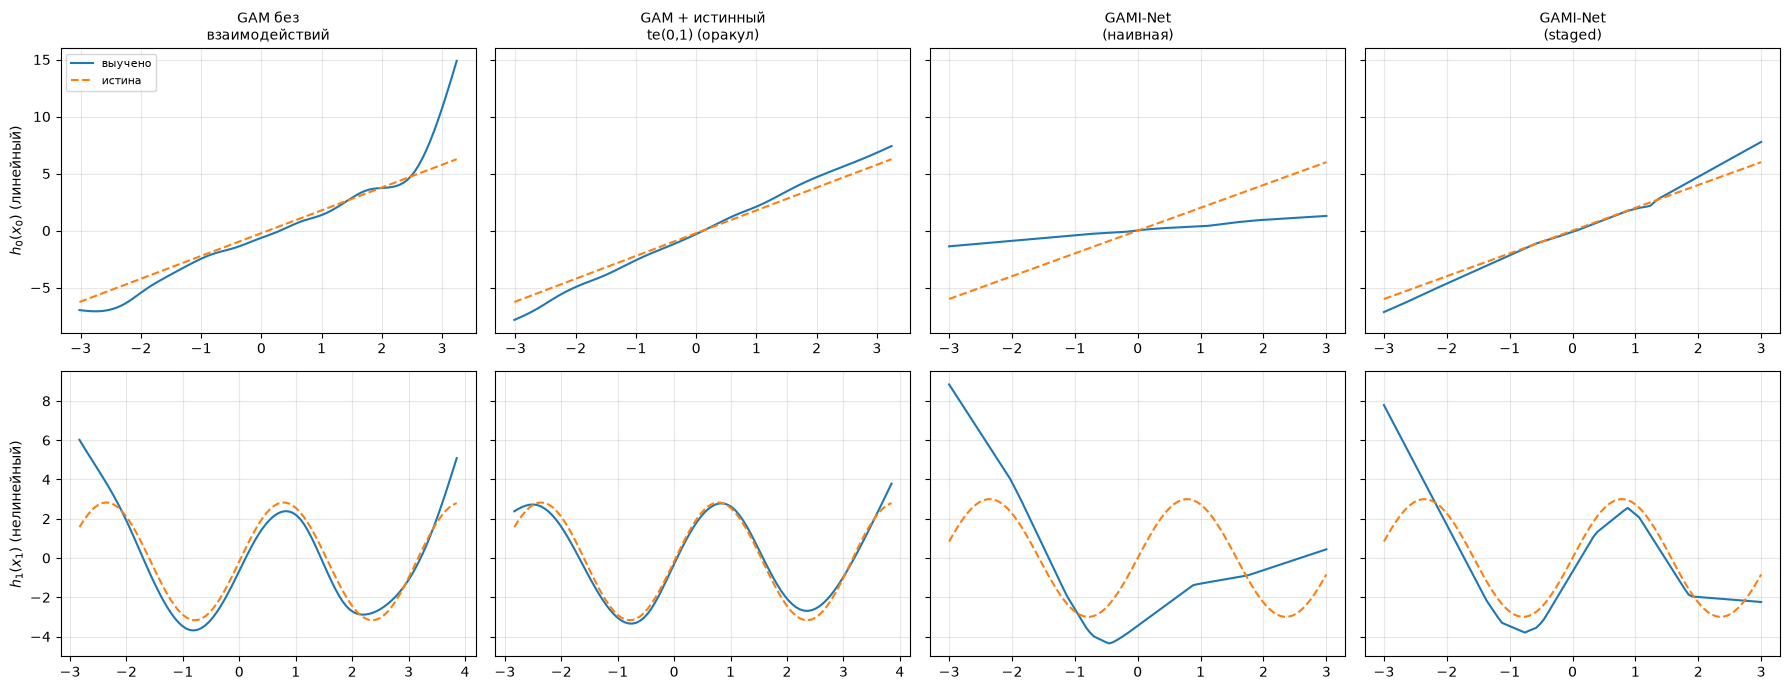

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey='row')
# gt
x_np = grid.squeeze().numpy()

columns = [
    ('GAM без\nвзаимодействий', (raw_base_x0, pdep_base_x0), (raw_base_x1, pdep_base_x1)),
    ('GAM + истинный\nte(0,1) (оракул)', (raw_gt_x0, pdep_gt_x0), (raw_gt_x1, pdep_gt_x1)),
    ('GAMI-Net\n(наивная)', (x_np, h0), (x_np, h1)),
    ('GAMI-Net\n(staged)', (x_np, h0_staged), (x_np, h1_staged)),
]

for col_idx, (title, (rx0, px0), (rx1, px1)) in enumerate(columns):
    ax0 = axes[0, col_idx]
    ax0.plot(rx0, px0 - px0.mean(), label='выучено')
    ax0.plot(rx0, true_h0(rx0) - true_h0(rx0).mean(), '--', label='истина')
    ax0.set_title(title, fontsize=10)
    ax0.grid(alpha=0.3)

    ax1 = axes[1, col_idx]
    ax1.plot(rx1, px1 - px1.mean(), label='выучено')
    ax1.plot(rx1, true_h1(rx1) - true_h1(rx1).mean(), '--', label='истина')
    ax1.grid(alpha=0.3)

axes[0, 0].set_ylabel('$h_0(x_0)$ (линейный)')
axes[1, 0].set_ylabel('$h_1(x_1)$ (нелинейный)')
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Сведение результатов:**

| Модель | $R^2$ | corr($h_0$) | corr($h_1$) |
|---|---|---|---|
| GAM без взаимодействий (pyGAM) | $0.752$ | $0.963$ | $0.938$ |
| GAM с истинным `te(0,1)` (pyGAM) | $0.976$ | $1.000$ | $0.989$ |
| GAMI-Net, наивное совместное обучение | $0.964$ | $0.998$ | $0.483$ |
| GAMI-Net, трёхэтапная процедура | $0.962$ | $0.998$ | $0.847$ |

- Лучший результат показывает pyGAM с заданным взаимодействием;
- Все модели, кроме наивной реализации GAMI-Net, почти теально посстанавливают линейный $h_0$; 
- Нелинейный $h_1$, синусоида корректно повторяют только классические GAM модели;
- Этапное обучение для GAMI-Net помогает модели выучить более корректную структуру зависимости;


**Почему так?** 

Мы рассмотрели синтетическую задачу, где при известных зависимостях механизм обучения внутри `pyGAM` обгоняет градиетный спуск. Это будет не всегда выполнено. Для `pyGAM` каждый $s(\cdot)$-терм — это пенализированный сплайн, который оценивается через классическую (штрафованную) регрессию по батчу базисных функций, а не сходится к решению через шумный градиентный спуск нескольких взаимно влияющих нейросетей сразу. Отсутсвие шума — лучшее обучение. 


**Главный вывод тут:** мы увидели, что высокий $R^2$ и честное, соответствующее реальности, несмещённое покомпонентное разложение — это **разные свойства модели**, и одно не гарантирует другого. Статистически обоснованная процедура (пенализированные сплайны) может обгонять более гибкую, но менее формально обоснованную нейросетевую реализацию именно в интерпретируемости — том самом качестве, ради которого GAM и GAMI-Net вообще строятся. Поэтому перед усложнением всегда надо идти от более простых методов. 

## Заключение

Мы рассмотрели все 3 надстройки над линейными моделями. Подсветим самые важные тезиси:

- **GLM** — верное распределение и верная link-функция дают верную шкалу для интерпретации $e^{\beta}$: шансы для Bernoulli, IRR для Poisson, мультипликативный эффект на среднее для Gamma. Неверная связь (Блок 3: $R^2\approx-239\to0.65$) или неверное распределение (Блок 2: overdispersion) — приводят к вариативности качества и не корректным выводам — это всё может привести к ложноположительным/ложноотрицательным результатам.

- **GAM** — гибкая модель, которая позволяет перейти от числа $\beta_j$ к функции $f_j(x_j)$. Но (Блок 4) функционая зависимость не универсальное решение. И здесь GAM всё ещё способны дать сильный прирост — при корректном добавлении terms со взаимодействиями. 

- **GAMI-Net** — помогает выйграть в необходимости выдвжиения гипотез о взаимосвязях, но может давать неустойчивые структуры, не совсем близкие к исходным зависимостям. Ограничения модели и структура обучения при этом важны, чтобы разложение приближалось к реальности максимально, а не просто "хорошо предсказывало в сумме".

Во всех трёх случаях мы платим за гибкость модели — каждый раз нужно больше времени и больше учтенны нюансов, чтобы проинтерпретировать модель правильно. Но мы выигрываем в том, что **в рамках обученной модели** прогноз всегда раскладывается на вклады.

Спасибо за изучение материала! Вы готовы двигаться к новым урокам =) 